# Notebook 02 — TF‑IDF + SVD + K‑Means + Similarité cosinus 

**Objectif**
Explorer des approches classiques de représentation et de regroupement des textes avant d’utiliser BERT.
Contenu :
- TF‑IDF pour vectoriser les textes
- SVD (LSA) pour réduire la dimension et obtenir des embeddings denses
- K‑Means pour regrouper les déclarations en 3 clusters
- Évaluation via ARI et silhouette score
- Analyse des clusters (mots les plus représentatifs)
- Similarité cosinus avec le “centre” des vrais → score simple de détection

**Pipeline :**
Montrer comment des méthodes classiques (TF‑IDF, LSA, clustering, cosinus) permettent déjà d’extraire une structure dans les données, avant de passer à des modèles plus avancés comme BERT.


## 0. Installation des dépendances et dataset

In [1]:
#imports
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from pathlib import Path

#Data
ROOT = Path("..").resolve()
STG_DIR = ROOT / "LIAR_DATA_SET" / "02_stg"

train = pd.read_csv(STG_DIR / "train_clean.csv")
test = pd.read_csv(STG_DIR / "test_clean.csv")
valid = pd.read_csv(STG_DIR / "valid_clean.csv")

texts = train["statement"].astype(str).tolist()
true_labels = train["label_binary"].values


## 1. TF-IDF

In [2]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )),
    ('svd', TruncatedSVD(
        n_components=200,
        random_state=42
    )),
    ('kmeans', KMeans(
        n_clusters=3,
        random_state=42,
        n_init=20,
        max_iter=600
    ))
])

Entraînement + prédiction

In [3]:
clusters = pipeline.fit_predict(texts)
print("Clustering terminé !")

Clustering terminé !


Evaluation : ARI + silhouette

In [4]:
# Récupération des embeddings LSA
X_svd = pipeline.named_steps['svd'].transform(
    pipeline.named_steps['tfidf'].transform(texts)
)

ari = adjusted_rand_score(true_labels, clusters)
sil = silhouette_score(X_svd, clusters)

print(f"ARI (vs vrais labels) : {ari:.3f}")
print(f"Silhouette score      : {sil:.3f}")

print("\nDistribution clusters vs vrais labels :")
print(pd.crosstab(true_labels, clusters, normalize='index'))

ARI (vs vrais labels) : 0.009
Silhouette score      : 0.026

Distribution clusters vs vrais labels :
col_0         0         1         2
row_0                              
0      0.690062  0.060383  0.249554
1      0.570063  0.039812  0.390125


Score mauvais : ARI à 0.009 => les clusters ne correspondent pas du tout aux labels vrai faux
Silhouette à 0.026 => les clusters se chevauchent, points presque équidistants des centres
Distribution : les deux classes se répartissent presque pareil, aucune séparation lexicale exploitable

Top des mots par cluster

In [5]:
def top_mots_cluster(tfidf, svd, kmeans, n_top=15):
    components = svd.components_          
    centers = kmeans.cluster_centers_     

    feature_names = tfidf.get_feature_names_out()

    for i, center in enumerate(centers):
        # projection inverse 
        tfidf_center = center @ components

        top_idx = tfidf_center.argsort()[-n_top:][::-1]
        print(f"\nCluster {i} :")
        print(", ".join(feature_names[top_idx]))

tfidf = pipeline.named_steps['tfidf']
svd = pipeline.named_steps['svd']
kmeans = pipeline.named_steps['kmeans']

top_mots_cluster(tfidf, svd, kmeans)


Cluster 0 :
to, the, says, and, for, on, in, of, that, is, has, was, obama, he, from

Cluster 1 :
health, care, health care, the, insurance, the health, health insurance, of, care law, to, law, for, reform, in, care reform

Cluster 2 :
the, in, of, in the, percent, of the, than, more, percent of, is, are, have, and, states, has


## 2. Similarité cosinus avec LSA

In [6]:
# Embeddings LSA
X_svd = svd.transform(tfidf.transform(texts))

# Moyenne des "vrais"
moyenne_vrais = X_svd[true_labels == 1].mean(axis=0)

# Similarité cosinus
sim_vrais = cosine_similarity(X_svd, moyenne_vrais.reshape(1, -1)).flatten()

train["cos_sim_vrais"] = sim_vrais

# Seuil = Q1 des vrais
seuil = np.percentile(sim_vrais[true_labels == 1], 25)

pred_cosinus = (sim_vrais < seuil).astype(int)

ari_cosinus = adjusted_rand_score(true_labels, pred_cosinus)
print(f"ARI similarité cosinus (LSA) : {ari_cosinus:.3f}")

print(f"Score médian vrais : {np.median(sim_vrais[true_labels == 1]):.3f}")
print(f"Score médian fakes : {np.median(sim_vrais[true_labels == 0]):.3f}")

ARI similarité cosinus (LSA) : 0.012
Score médian vrais : 0.252
Score médian fakes : 0.234


Visualisation simple des clusters

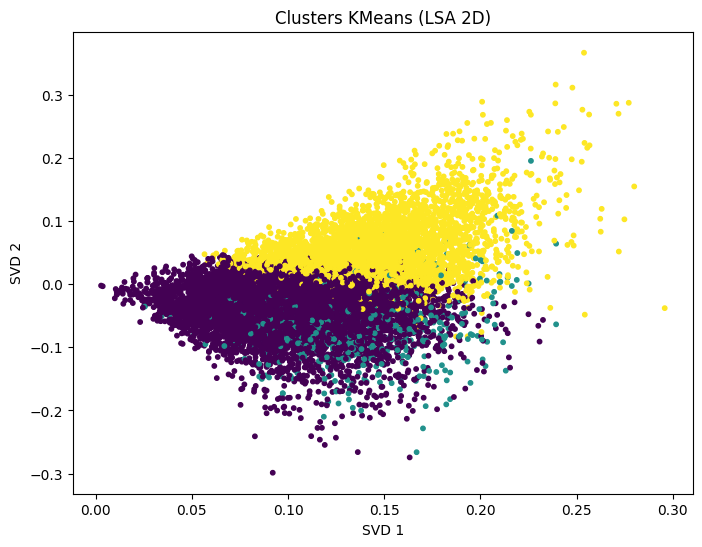

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_svd[:,0], X_svd[:,1], c=clusters, cmap="viridis", s=10)
plt.title("Clusters KMeans (LSA 2D)")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.show()

## 3. TF IDF + One Hot Encoder pour les features meta + SVD + KMeans

On tente une autre approche => TF IDF + One hont encoder pour les features meta + SVD + K Means

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score


In [9]:
#Définition des features meta
meta_features = ["speaker", "party_group", "subject", "context"]
#on garde party plutôt que party groupe sinon répétition

Pré processeur TF IDF + One Hot Encoder

In [10]:
preprocess = ColumnTransformer([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    ), "statement"),

    ("meta", OneHotEncoder(
        handle_unknown="ignore"
    ), meta_features)
])

Pipeline preprocess SVD Kmeans

In [11]:
pipeline = Pipeline([
    ("prep", preprocess),

    ("svd", TruncatedSVD(
        n_components=300,
        random_state=42
    )),

    ("kmeans", KMeans(
        n_clusters=3,
        random_state=42,
        n_init=20,
        max_iter=600
    ))
])

Entraînement et prédiction

In [12]:
clusters = pipeline.fit_predict(train)
print("Clustering terminé !")

Clustering terminé !


Evaluation

In [13]:
X_svd = pipeline.named_steps["svd"].transform(
    pipeline.named_steps["prep"].transform(train)
)

ari = adjusted_rand_score(true_labels, clusters)
sil = silhouette_score(X_svd, clusters)

print(f"ARI (vs vrais labels) : {ari:.3f}")
print(f"Silhouette score      : {sil:.3f}")

print("\nDistribution clusters vs vrais labels :")
print(pd.crosstab(true_labels, clusters, normalize='index'))

ARI (vs vrais labels) : 0.012
Silhouette score      : 0.243

Distribution clusters vs vrais labels :
col_0         0         1         2
row_0                              
0      0.499109  0.249777  0.251114
1      0.392385  0.223401  0.384214


Par rapport à nos résultats précédents :
Le silhouette score monte fortement => les clusters sont cohérents, le mélange TF IDF + meta features a révélé des groupes réels

L'ARI reste très faible => les clusters ne correspondent pas aux labels vrai faux, ce qui n'est pas étonnant car la vérité n'est pas corrélée au vocab aux sujets ou au parti

La distribution montre que les clusters ne correspondent pas aux labels vrai faux => les deux classes se répartissent presque pareil

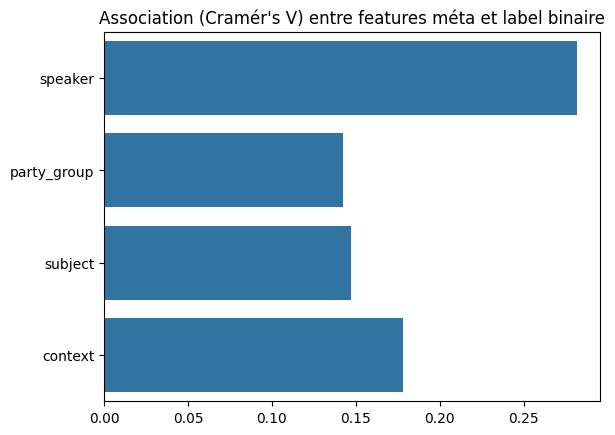

In [14]:
import scipy.stats as ss
import numpy as np
import seaborn as sns

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

meta_cols = ["speaker", "party_group", "subject", "context"]

scores = {
    col: cramers_v(train[col], train["label_binary"])
    for col in meta_cols
}

scores

sns.barplot(x=list(scores.values()), y=list(scores.keys()))
plt.title("Association (Cramér's V) entre features méta et label binaire")
plt.show()

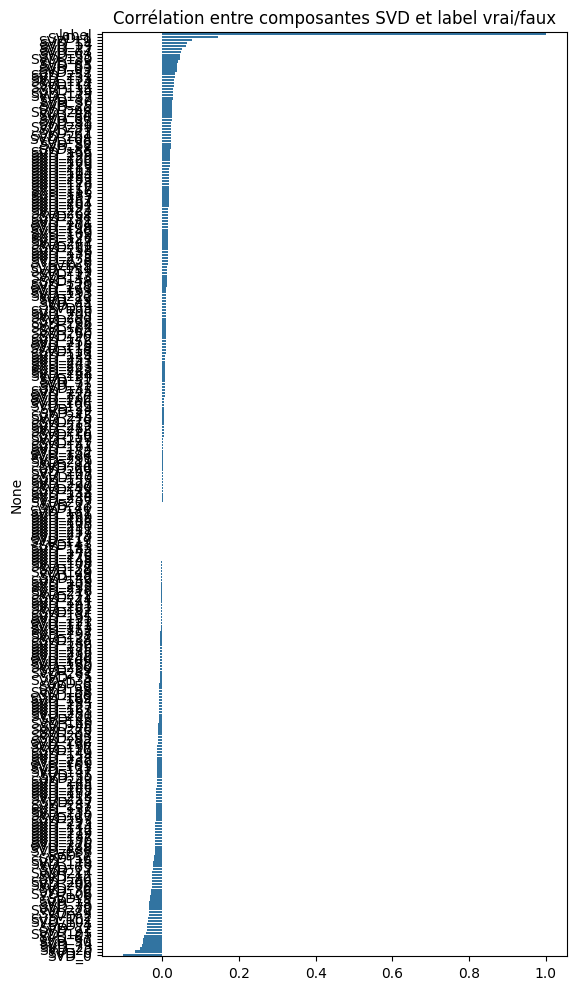

In [15]:
# Embeddings SVD
X_svd = pipeline.named_steps["svd"].transform(
    pipeline.named_steps["prep"].transform(train)
)

svd_df = pd.DataFrame(X_svd, columns=[f"SVD_{i}" for i in range(X_svd.shape[1])])
svd_df["label"] = true_labels

corr_svd = svd_df.corr()["label"].sort_values(ascending=False)

plt.figure(figsize=(6,12))
sns.barplot(x=corr_svd.values, y=corr_svd.index)
plt.title("Corrélation entre composantes SVD et label vrai/faux")
plt.show()

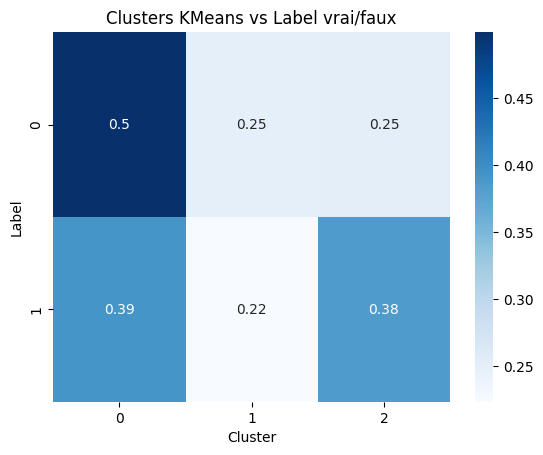

In [16]:
ct = pd.crosstab(true_labels, clusters, normalize="index")

sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Clusters KMeans vs Label vrai/faux")
plt.xlabel("Cluster")
plt.ylabel("Label")
plt.show()

=> la matrice de contingence confirme que les clusters ne séparent pas bien le vrai faux

## TF IDF Binaire

In [17]:
mapping_binary = {
    "pants-fire": 0,
    "false": 0,
    "barely-true": 0,
    "half-true": 1,
    "mostly-true": 1,
    "true": 1
}

for df in [train, valid, test]:
    df["label_binary"] = df["label"].map(mapping_binary)

In [18]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )),
    ('svd', TruncatedSVD(
        n_components=200,
        random_state=42
    )),
    ('kmeans', KMeans(
        n_clusters=2,
        random_state=42,
        n_init=20,
        max_iter=600
    ))
])

pipeline.fit(train["statement"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [19]:
#embeddings lsa
X_train_svd = pipeline.named_steps['svd'].transform(
    pipeline.named_steps['tfidf'].transform(train["statement"])
)

clusters_train = pipeline.named_steps['kmeans'].predict(X_train_svd)

In [20]:
#eval sur train
true_labels = train["label_binary"].values

ari = adjusted_rand_score(true_labels, clusters_train)
sil = silhouette_score(X_train_svd, clusters_train)

print(f"ARI (vs vrais labels binaires) : {ari:.3f}")
print(f"Silhouette score               : {sil:.3f}")

print("\nDistribution clusters vs vrais labels :")
print(pd.crosstab(true_labels, clusters_train, normalize='index'))

ARI (vs vrais labels binaires) : 0.009
Silhouette score               : 0.024

Distribution clusters vs vrais labels :
col_0         0         1
row_0                    
0      0.263146  0.736854
1      0.408554  0.591446


In [21]:
#similarité cosinus
tfidf = pipeline.named_steps['tfidf']
svd = pipeline.named_steps['svd']

X_train_svd = svd.transform(tfidf.transform(train["statement"]))

moyenne_real = X_train_svd[train["label_binary"] == 1].mean(axis=0)

sim_real = cosine_similarity(X_train_svd, moyenne_real.reshape(1, -1)).flatten()

train["cos_sim_real"] = sim_real

seuil = np.percentile(sim_real[train["label_binary"] == 1], 25)

pred_cosinus = (sim_real < seuil).astype(int)

ari_cosinus = adjusted_rand_score(train["label_binary"], pred_cosinus)

print(f"ARI similarité cosinus (LSA) : {ari_cosinus:.3f}")

ARI similarité cosinus (LSA) : 0.012


ARI presque 0 = aléatoire. La similarité cosinus ne sépare pas fake/real

Les méthodes classiques (TF‑IDF, LSA, KMeans, cosinus) échouent à séparer les classes, ce qui confirme que la distinction vrai/faux repose sur des signaux contextuels plus subtils que le simple vocabulaire. Cela justifie l’utilisation d’un modèle transformer.